In [1]:
import numpy as np
import pandas as pd


In [2]:
df = pd.read_csv('spam.csv')

In [3]:
df.sample(20)

,Category,Message
4244,ham,Okie...
5307,ham,What you did in leave.
4545,ham,when you and derek done with class?
109,ham,I know! Grumpy old people. My mom was like you...
3463,spam,Bloomberg -Message center +447797706009 Why wa...
1885,ham,I love your ass! Do you enjoy doggy style? :)
4869,ham,"Watching cartoon, listening music &amp; at eve..."
2381,ham,"If i let you do this, i want you in the house ..."
1724,ham,"Hi Jon, Pete here, Ive bin 2 Spain recently & ..."
4713,ham,Thats cool princess! I will cover your face in...


In [4]:
df.shape

(5572, 2)

In [1]:
#1. data cleaning
#2 EDA
#3 text preprocessing
#4 Model building


## 1 DATA Cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [7]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()


In [8]:
df['Category']=encoder.fit_transform(df['Category'])

In [9]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
#missing values
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [11]:
#check for duplicate values
df.duplicated().sum()

np.int64(415)

In [12]:
#remove duplicates
df= df.drop_duplicates(keep='first')


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.shape

(5157, 2)

## 2 EDA(Exploratory Data Analysis)

In [15]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
df['Category'].value_counts()

Category
0    4516
1     641
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x22866f6be00>,
 [Text(-1.0171946362150524, 0.41870642705280725, 'ham'),
  Text(1.0171945729921292, -0.4187065806449194, 'spam')])

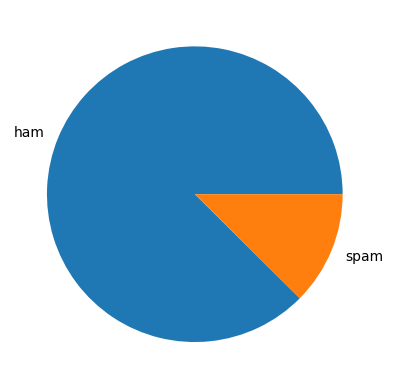

In [17]:
import matplotlib.pyplot as plt
plt.pie(df['Category'].value_counts(),labels=['ham','spam'])

In [18]:
# data is imbalanced

In [19]:
import nltk

In [20]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to C:\Users\shruti
[nltk_data]     shukla\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [21]:
df['num_characters']=df['Message'].apply(len)

In [22]:
df.head()

,Category,Message,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [23]:
# num of words
df['Message'].apply(lambda x:nltk.word_tokenize(x))

0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568      [Will, ü, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: Message, Length: 5157, dtype: object

In [24]:
# num of words
df['num_words']=df['Message'].apply(lambda x:len(nltk.word_tokenize(x)))

In [25]:
df.head()

,Category,Message,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [26]:
df['num_sentences']=df['Message'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [27]:
df.head()

,Category,Message,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [28]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5157.000000,5157.000000,5157.000000
mean,79.103936,18.560403,1.969750
std,58.382922,13.405970,1.455526
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.000000
75%,118.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
# for ham msg
df[df['Category'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.869353,17.267715,1.827724
std,56.708301,13.588065,1.394338
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,53.000000,13.000000,1.000000
75%,91.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [30]:
# for spam msg
df[df['Category'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,641.000000,641.000000,641.000000
mean,137.118565,27.667707,2.970359
std,30.399707,7.103501,1.485575
min,7.000000,2.000000,1.000000
25%,130.000000,25.000000,2.000000
50%,148.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,223.000000,46.000000,9.000000


In [31]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

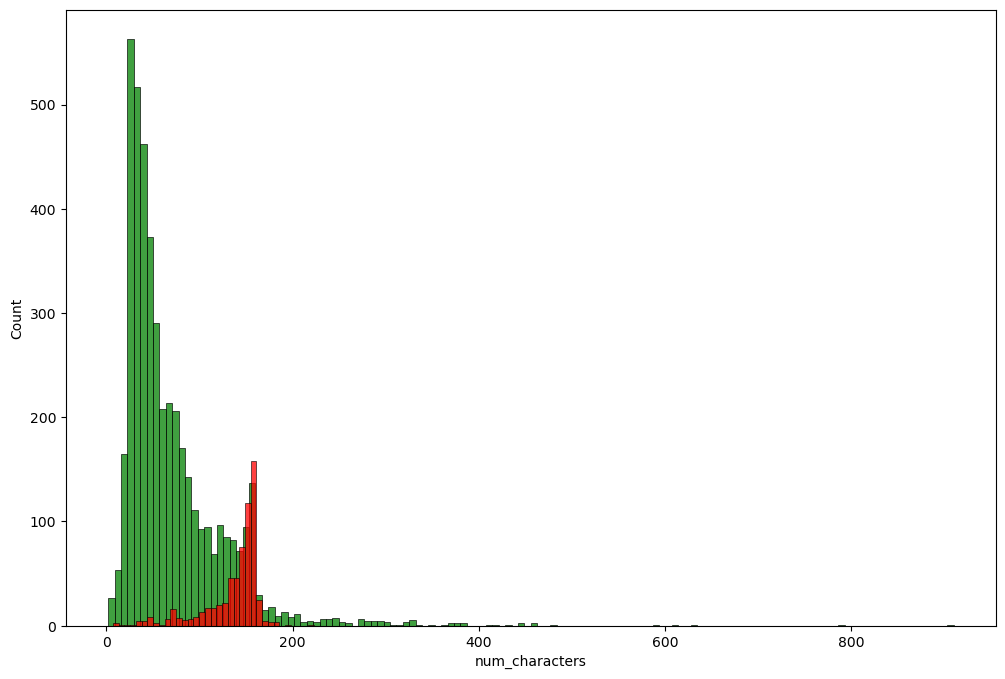

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
sns.histplot(df[df['Category'] ==0]['num_characters'],color='green')
sns.histplot(df[df['Category'] ==1]['num_characters'],color='red')


<Axes: xlabel='num_words', ylabel='Count'>

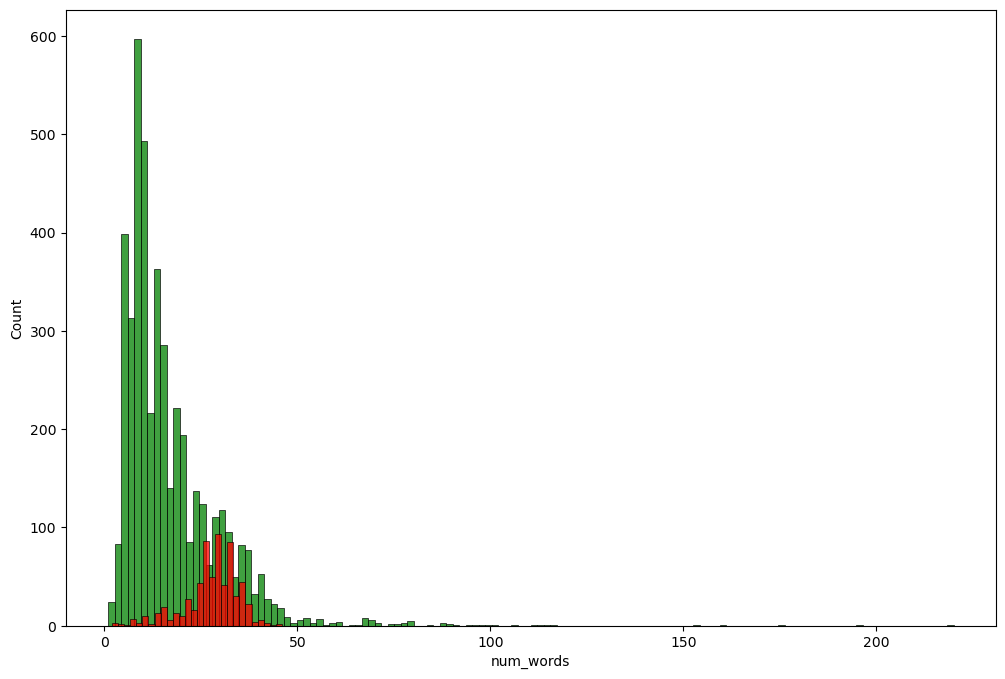

In [33]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['Category'] ==0]['num_words'],color='green')
sns.histplot(df[df['Category'] ==1]['num_words'],color='red')



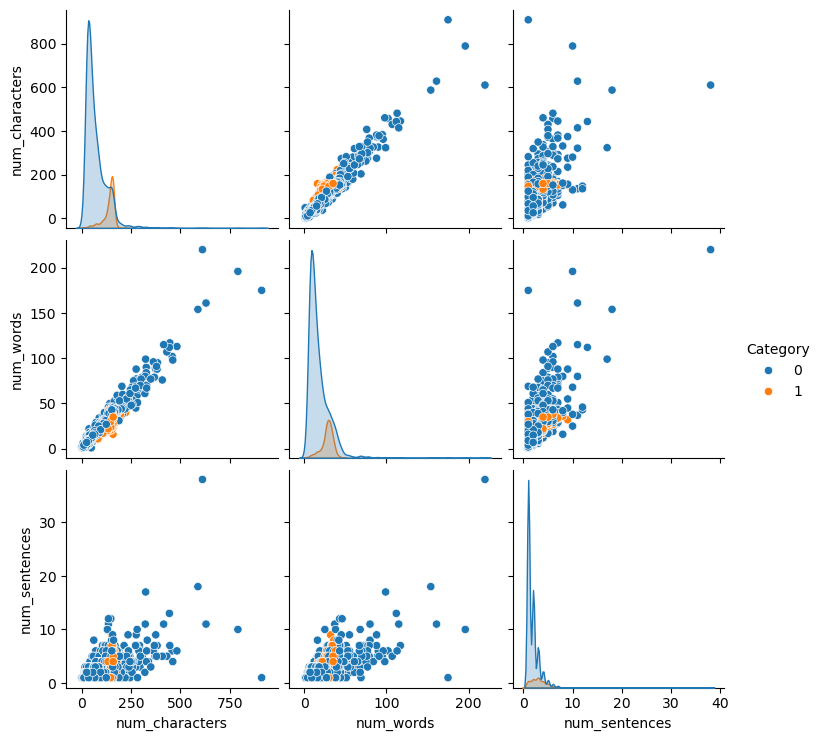

In [34]:
sns.pairplot(df,hue='Category')

<Axes: >

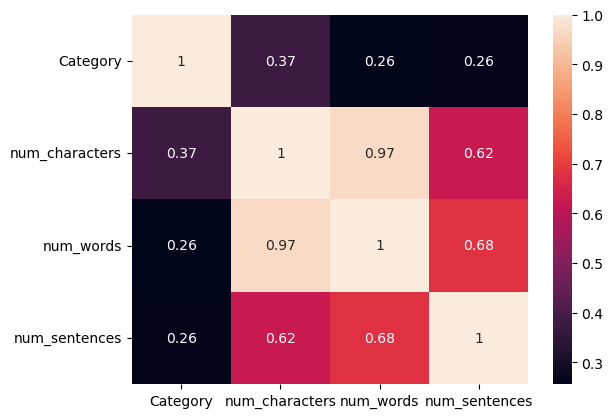

In [35]:
sns.heatmap(df.corr(numeric_only=True),annot= True)

## 3 DATA Preprocessing
   .lower case  
   
   .Tokenization  
     
   .Removeing special characters  
   
   .Removing stop words and punctuation  
   
   .Streamining  
   

In [36]:
import nltk
import string
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to C:\Users\shruti
[nltk_data]     shukla\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [37]:
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [38]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [39]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [40]:
df['Message'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [41]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [42]:
df['Message'].apply(transform_text)

0       go jurong point crazi avail bugi n great world...
1                                   ok lar joke wif u oni
2       free entri 2 wkli comp win fa cup final tkt 21...
3                     u dun say earli hor u c alreadi say
4                    nah think goe usf live around though
                              ...                        
5567    2nd time tri 2 contact u pound prize 2 claim e...
5568                              ü b go esplanad fr home
5569                                    piti mood suggest
5570    guy bitch act like interest buy someth els nex...
5571                                       rofl true name
Name: Message, Length: 5157, dtype: object

In [43]:
df['transformed_text']=df['Message'].apply(transform_text)

In [44]:
 df.head()

,Category,Message,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [45]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


In [46]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [47]:
print(df[df['Category'] == 1]['transformed_text'].head())

2     free entri 2 wkli comp win fa cup final tkt 21...
5     freemsg hey darl 3 week word back like fun sti...
8     winner valu network custom select receivea pri...
9     mobil 11 month u r entitl updat latest colour ...
11    six chanc win cash 100 pound txt csh11 send co...
Name: transformed_text, dtype: object


In [48]:
spam_wc = wc.generate(df[df['Category'] == 0]['transformed_text'].str.cat(sep=" ")) 


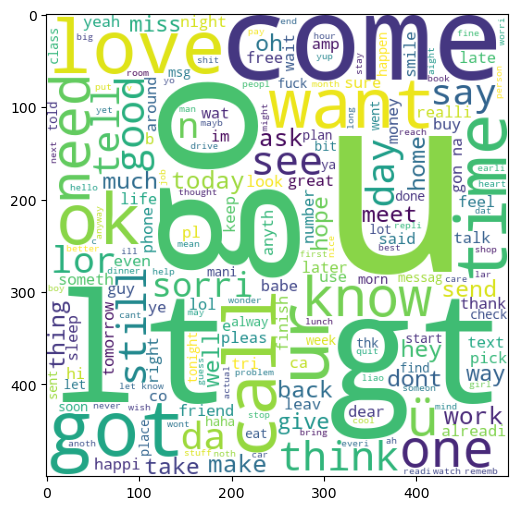

In [49]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [50]:
ham_wc = wc.generate(df[df['Category'] == 1]['transformed_text'].str.cat(sep=" "))

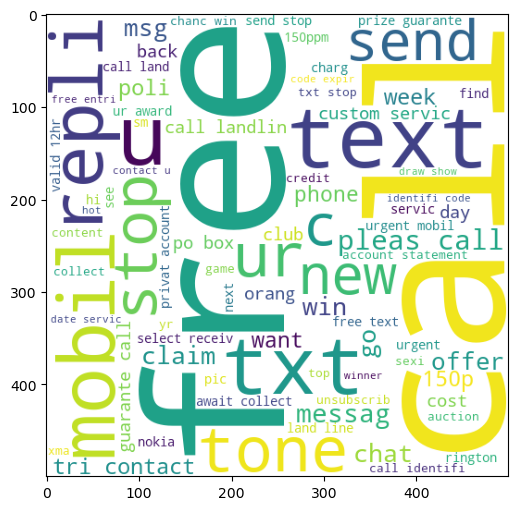

In [51]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [52]:
df.head()

,Category,Message,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [53]:
spam_corpus = []
for msg in df[df['Category'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [54]:
len(spam_corpus)

9781

In [55]:
from collections import Counter

In [56]:
import seaborn as sns
import pandas as pd

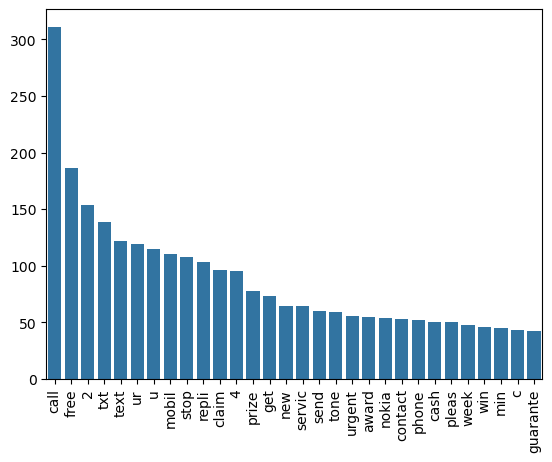

In [57]:
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0].tolist(), y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1].tolist())
plt.xticks(rotation = 'vertical')
plt.show()

In [58]:
ham_corpus = []
for msg in df[df['Category'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [59]:
len(ham_corpus)

35940

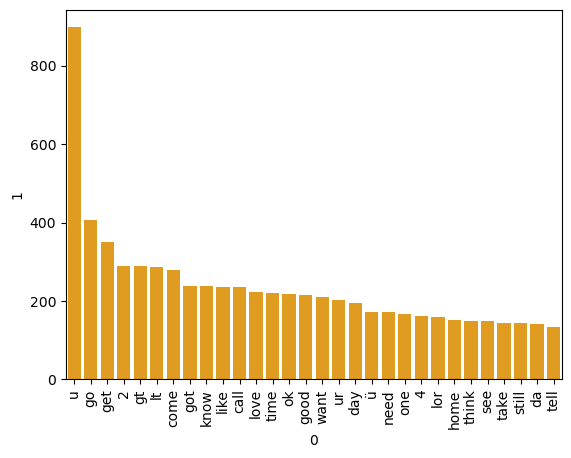

In [60]:
sns.barplot(x = pd.DataFrame(Counter(ham_corpus).most_common(30)) [0], color = 'orange',y = pd.DataFrame(Counter(ham_corpus).most_common(30)) [1])
plt.xticks(rotation = 'vertical')
plt.show()

## 4 Model Building

In [61]:
import sklearn

In [62]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer

In [63]:
def transform_text(text):
    text = str(text).lower()
    return text

In [64]:
df['transformed_text'] = df['Message'].apply(transform_text)

In [65]:
print(df.columns)

Index(['Category', 'Message', 'num_characters', 'num_words', 'num_sentences',
       'transformed_text'],
      dtype='object')


In [66]:
x = cv.fit_transform(df['transformed_text']).toarray()

In [67]:
print(type(x))

<class 'numpy.ndarray'>


In [68]:
x.shape

(5157, 8709)

In [69]:
y = df['Category'].values

In [70]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5157,))

In [71]:
from sklearn.model_selection import train_test_split

In [72]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [73]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [74]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [75]:
print(type(x_train))
print(x_train[:2])

<class 'numpy.ndarray'>
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [76]:
print(y_train[:10])

[1 0 0 0 0 0 0 0 0 0]


In [77]:
print(df['Category'].unique())

[0 1]


In [78]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['Category'] = encoder.fit_transform(df['Category'])
y = df['Category']

In [79]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=2
)

In [80]:
print(type(x))
print(x.shape)

print(type(x_train))
print(x_train.shape)

<class 'numpy.ndarray'>
(5157, 8709)
<class 'numpy.ndarray'>
(4125, 8709)


In [81]:
print(type(x))
print(type(y))

<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>


In [82]:
gnb.fit(x_train, y_train)

y_pred1 = gnb.predict(x_test)

print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.9050387596899225
[[820  85]
 [ 13 114]]
0.5728643216080402


In [83]:
mnb.fit(x_train,y_train)
y_pred1 = mnb.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.9777131782945736
[[889  16]
 [  7 120]]
0.8823529411764706


In [84]:
bnb.fit(x_train,y_train)
y_pred1 = bnb.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.9825581395348837
[[904   1]
 [ 17 110]]
0.990990990990991


In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [86]:
svc = SVC(kernel='sigmoid', gamma=1.0,max_iter=1000)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')

In [87]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB' : mnb,
    'DT' : dtc,
    'LR' : lrc
}

In [88]:
from sklearn.model_selection import train_test_split

In [89]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [90]:
from sklearn.metrics import accuracy_score, precision_score

In [91]:
def train_classifier(clf,x_train, y_train, x_test, y_test):
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    return accuracy, precision

In [92]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score

# 1. Define the model (MultinomialNB is the fastest and best for SMS spam)
mnb = MultinomialNB()

# 2. Train the model directly here
mnb.fit(x_train, y_train)

# 3. Make predictions
y_pred = mnb.predict(x_test)

# 4. Print the final results
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("Precision Score: ", precision_score(y_test, y_pred))

Accuracy Score :  0.9777131782945736
Precision Score:  0.8823529411764706


In [93]:
from sklearn.metrics import accuracy_score, precision_score
accuracy_scores = []
precision_scores = []
for name, clf in clfs.items():
    print('Training:',name)
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    
    # This fills your lists from 0 up to 11
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    precision_scores.append(precision_score(y_test, y_pred, average='macro'))
    print(name,'done')

Training: SVC
SVC done
Training: KN
KN done
Training: NB
NB done
Training: DT
DT done
Training: LR


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


LR done


In [94]:
print("Algorithms:", len(clfs.keys()))
print("Accuracy:", len(accuracy_scores))
print("Precision:", len(precision_scores))

Algorithms: 5
Accuracy: 5
Precision: 5


In [95]:
performance_df = pd.DataFrame({'Algorithms':clfs.keys(),'Accuracy':accuracy_scores,'precision':precision_scores})

In [96]:
performance_df

,Algorithms,Accuracy,precision
0,SVC,0.858527,0.676353
1,KN,0.912791,0.954774
2,NB,0.977713,0.937270
3,DT,0.947674,0.900561
4,LR,0.978682,0.979991


In [97]:
print(performance_df.columns)

Index(['Algorithms', 'Accuracy', 'precision'], dtype='object')


In [98]:
performance_df1 = pd.melt(performance_df,id_vars = 'Algorithms')

In [99]:
performance_df1

,Algorithms,variable,value
0,SVC,Accuracy,0.858527
1,KN,Accuracy,0.912791
2,NB,Accuracy,0.977713
3,DT,Accuracy,0.947674
4,LR,Accuracy,0.978682
5,SVC,precision,0.676353
6,KN,precision,0.954774
7,NB,precision,0.937270
8,DT,precision,0.900561
9,LR,precision,0.979991


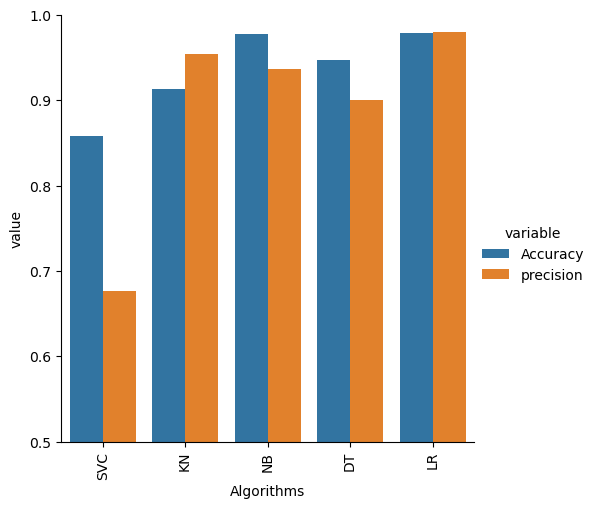

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.catplot(x = 'Algorithms',y = 'value',
            hue = 'variable',data = performance_df1,kind = 'bar' , height = 5)
plt.ylim(0.5,1.0)
plt.xticks(rotation = 'vertical')
plt.show()
            

In [101]:
import pickle

In [102]:
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))    